## Task 2: simple baseline model

Import all the dependencies en setup the Keras backend. You select the backend you want to use and change os.environ based on the availability of a GPU to accelerate computation. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.metrics as metrics
import seaborn as sns
import pandas as pd

In [2]:
import os

# Set Keras backend (can be 'tensorflow', 'torch', 'jax')
os.environ["KERAS_BACKEND"] = "torch"

# CPU only
# os.environ["CUDA_VISIBLE_DEVICES"] = ""

# Specific GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [3]:
import keras
from keras import layers, optimizers, losses

In [4]:
print(f"Keras backend: {keras.backend.backend()}")

Keras backend: torch


Load the data from the preprocessing notebook

In [5]:
X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")
X_val = np.load("X_val.npy")
y_val = np.load("y_val.npy")
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")
X_test_no_normalized = np.load("X_test_no_norm.npy")
y_test_no_normalized = np.load("y_test_no_norm.npy")

### Step 1: 

Set up classification and choose metrics to eveluate the classifier. Because the model will be used in a medical context, the metrics
will be adapted to this. We will use:
 - Accuracy
 - Recall
 - Specifity
 - ROC-AUC

### Step 2: 
Build the initial model. The architecture is as follows:

| Layer | Output shape | Description |
|---|---|---|
| Input | 128 × 128 × 1 | Grayscale X-ray image |
| Conv2D(32, 3×3, same) + BN + ReLU | 128 × 128 × 32 | Detect low-level features (edges, gradients) |
| MaxPooling2D(2×2) | 64 × 64 × 32 | Downsample, retain strongest activations |
| Conv2D(64, 3×3, same) + BN + ReLU | 64 × 64 × 64 | Detect mid-level features (textures, shapes) |
| MaxPooling2D(2×2) | 32 × 32 × 64 | Downsample again |
| Conv2D(128, 3×3, same) + BN + ReLU | 32 × 32 × 128 | Detect high-level features (structures, patterns) |
| MaxPooling2D(2×2) | 16 × 16 × 128 | Final spatial compression |
| Flatten | 32768 | Reshape feature maps to 1D vector |
| Dense(256) + ReLU | 256 | Learn combinations of extracted features |
| Dropout(0.5) | 256 | Regularisation, prevent overfitting |
| Dense(1) + Sigmoid | 1 | Output P(disease) for binary classification |

In [6]:
model = keras.Sequential(
    [
        layers.Input(shape=(128, 128, 1)),
        # Block 1: Convolution + Pooling
        layers.Conv2D(32, kernel_size=(3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        # Block 2: Convolution + Pooling
        layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        # Block 3: Convolution + Pooling
        layers.Conv2D(128, kernel_size=(3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        # Flatten
        layers.Flatten(),
        # Classification head
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,129 (16.36 MB)

 Trainable params: 4,287,681 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

## Step 3: train the model

The training will be done using the **binairy cross entropy** loss function. This function penalyses confident wrong mispredictions. If the model predicts P(disease) = 0.95 and the true label is 0, the log term produceses a large loss. When the model is confidently correct, the loss approaches 0. It pairs good with the sigmoid activation of the last layer in the network. Because this layer squashes the output to the [0,1] interval, the ouput can be interpreted as a probability and in turn can be used in the cross entropy function.

For model evaluation the metrics mentioned in step 1 will be used.

## 

In [7]:
"""Helper function to compile new models with the same settings and architecture"""

def build_model():

    optimizer = optimizers.Adam(learning_rate=0.0001)
    loss = losses.BinaryCrossentropy()
    model = keras.Sequential(
        [
            layers.Input(shape=(128, 128, 1)),
            # Block 1: Convolution + Pooling
            layers.Conv2D(32, kernel_size=(3, 3), padding="same"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D(pool_size=(2, 2)),
            # Block 2: Convolution + Pooling
            layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D(pool_size=(2, 2)),
            # Block 3: Convolution + Pooling
            layers.Conv2D(128, kernel_size=(3, 3), padding="same"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D(pool_size=(2, 2)),
            # Flatten
            layers.Flatten(),
            # Classification head
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.5),
            layers.Dense(1, activation="sigmoid"),
        ]
    )
    model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])
    return model

In [8]:
from keras.callbacks import ReduceLROnPlateau

#callback to reduce learning rate when validation loss plateaus to help convergence
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.2, patience=3, min_lr=1e-6, verbose=1
)

In [9]:
keras.backend.clear_session()
model = build_model()
history = model.fit(
    X_train,
    y_train,
    batch_size=16,
    epochs=20,
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr],
)

Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 28s 300ms/step - accuracy: 0.6333 - loss: 0.7461 - val_accuracy: 0.6226 - val_loss: 0.6812 - learning_rate: 1.0000e-04
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 26s 281ms/step - accuracy: 0.6613 - loss: 0.6069 - val_accuracy: 0.6164 - val_loss: 0.6765 - learning_rate: 1.0000e-04
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 28s 295ms/step - accuracy: 0.6827 - loss: 0.5907 - val_accuracy: 0.6415 - val_loss: 0.6430 - learning_rate: 1.0000e-04
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 26s 282ms/step - accuracy: 0.6780 - loss: 0.5624 - val_accuracy: 0.6918 - val_loss: 0.6306 - learning_rate: 1.0000e-04
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 25s 271ms/step - accuracy: 0.7200 - loss: 0.5143 - val_accuracy: 0.7484 - val_loss: 0.5873 - learning_rate: 1.0000e-04
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 25s 264ms/step - accuracy: 0.7493 - loss: 0.4779 - val_accuracy: 0.7233 - val_loss: 0.5512 - learning_rate: 1.0000e-04
Epoch 7/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 27s 292ms/step - acc

In [10]:
def plot_training_history_with_val(history, ax=None, title=None):
    if ax is None:
        _, ax = plt.subplots()
    ax.plot(history.history["accuracy"], label="Train Accuracy")
    ax.plot(history.history["val_accuracy"], label="Validation Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.legend(loc="lower right")
    return ax

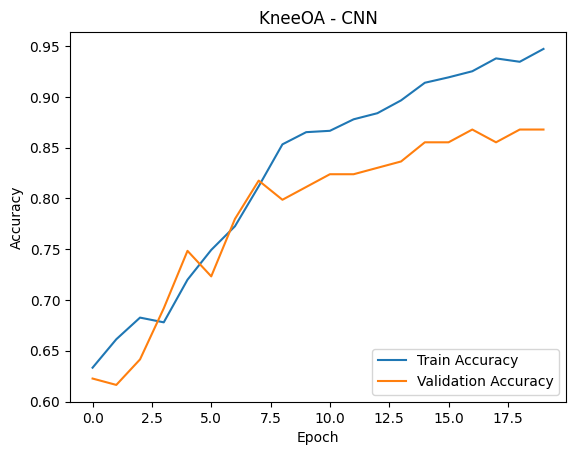

In [11]:
plot_training_history_with_val(history, title="KneeOA - CNN")
plt.show()

### Step 5: Final baseline

In [12]:
X_test = np.concatenate([X_test, X_val])
y_test = np.concatenate([y_test, y_val])

In [13]:
keras.backend.clear_session()
model_final = build_model()
history_final = model_final.fit(
    X_train,
    y_train,
    batch_size=16,
    epochs=20,
)

Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 22s 236ms/step - accuracy: 0.6287 - loss: 0.7895
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 24s 260ms/step - accuracy: 0.6893 - loss: 0.5823
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 23s 245ms/step - accuracy: 0.7000 - loss: 0.5604
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 23s 243ms/step - accuracy: 0.7247 - loss: 0.5168
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 24s 259ms/step - accuracy: 0.7660 - loss: 0.4660
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 26s 278ms/step - accuracy: 0.7980 - loss: 0.4257
Epoch 7/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 25s 261ms/step - accuracy: 0.8160 - loss: 0.3746
Epoch 8/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 25s 265ms/step - accuracy: 0.8527 - loss: 0.3357
Epoch 9/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 26s 271ms/step - accuracy: 0.8720 - loss: 0.2973
Epoch 10/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 26s 279ms/step - accuracy: 0.8700 - loss: 0.2727
Epoch 11/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 27s 284ms/step - accuracy: 0.8940 - loss: 0.2372
Epoch 12/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 26

In [14]:
def plot_training_history(history, ax=None, title=None):
    if ax is None:
        _, ax = plt.subplots()
    ax.plot(history.history["accuracy"], label="Train Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.legend(loc="lower right")
    return ax

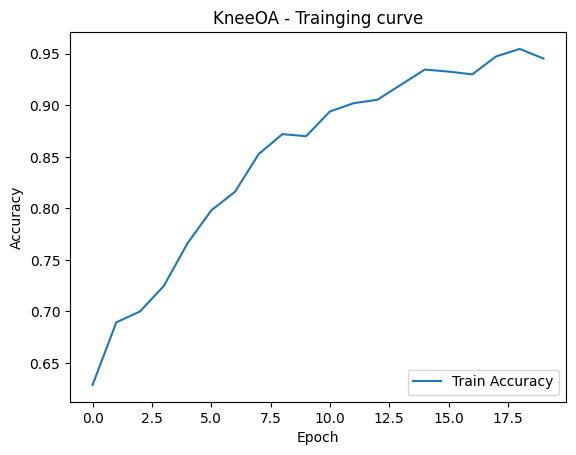

In [15]:
plot_training_history(history_final, title="KneeOA - Trainging curve")
plt.show()

In [18]:
import os
os.makedirs("baseline_model", exist_ok=True)
model_final.save("baseline_model/baseline_final.keras")

I0000 00:00:1777564032.985057   27670 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777564035.019705   27670 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [19]:
test_model = keras.models.load_model("baseline_model/baseline_final.keras")

In [20]:
#helper function to plot confusion matrix in a more intuitive way (TP, FP, FN, TN)
def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, title: str) -> None:
    cnf_matrix = metrics.confusion_matrix(
        y_true, y_pred
    )  # Returns [[TN, FP], [FN, TP]]

    # Rearrange to match [[TP, FP], [FN, TN]]
    rearranged = np.array(
        [
            [cnf_matrix[1, 1], cnf_matrix[0, 1]],  # TP, FP  (row0: Predicted Positive)
            [cnf_matrix[1, 0], cnf_matrix[0, 0]],  # FN, TN  (row1: Predicted Negative)
        ]
    )
    print(title, f'TP={cnf_matrix[1, 1]}', f'FP={cnf_matrix[0, 1]}', f'FN={cnf_matrix[1, 0]}', f'TN={cnf_matrix[0, 0]}' )
    ax = sns.heatmap(
        pd.DataFrame(rearranged), annot=True, cmap="Blues", fmt="g", cbar=False
    )
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")
    ax.set_xlabel("Actual", fontsize=12)
    ax.set_ylabel("Predicted", fontsize=12)
    ax.set_xticklabels(["Positive", "Negative"], fontsize=10)
    ax.set_yticklabels(["Positive", "Negative"], fontsize=10)
    plt.tight_layout()
    plt.title(title, fontsize=14, fontweight="bold")
    plt.show()

For evaluation, first we want to look at the accuracy. 

In [21]:
y_pred_prob = test_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(y_pred.shape, y_test.shape)

test_acc = np.mean(y_pred.flatten() == y_test)
print(f"Test Accuracy: {test_acc:.4f}")


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step
(305, 1) (305,)
Test Accuracy: 0.8984


For medial data accuracy is not a good metric so use other metrics instead. The fraction of patients that have the disease and actually get diagnosed (recall), and of the patients that dont have the disease and dont get diagnosed (specificity), will give more insight in how the model is actually performing. Recall should be high because false negatives have a high impact on patients lives. On the other side, maximizing specificity will help the healthcare system save resources and prevent unnecessary treatment on patients. 

Recall: 0.7788
Specificity: 0.9688
ROC AUC Score: 0.9404
Baseline model - Confusion Matrix, threshold=0.5 TP=88 FP=6 FN=25 TN=186


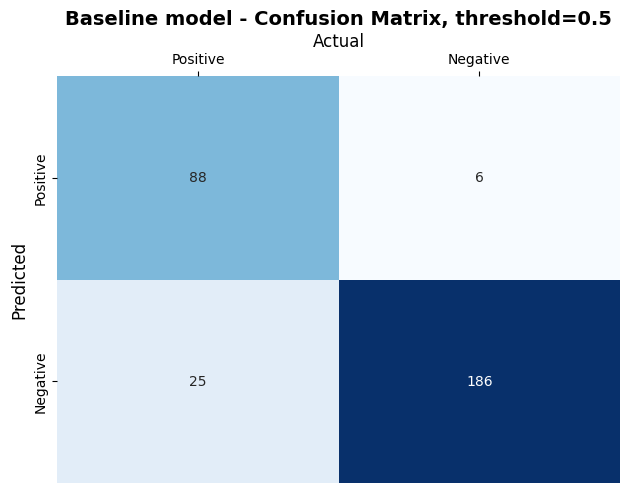

In [22]:
recall_score = metrics.recall_score(y_test, y_pred)
specificity_score = metrics.recall_score(y_test, y_pred, pos_label=0)
roc_auc_score = metrics.roc_auc_score(y_test, y_pred_prob)

print(f"Recall: {recall_score:.4f}")
print(f"Specificity: {specificity_score:.4f}")
print(f"ROC AUC Score: {roc_auc_score:.4f}")
plot_confusion_matrix(y_test, y_pred, title="Baseline model - Confusion Matrix, threshold=0.5")

Now some examples to get a feeling for how good the model did. A green label means the model predicted correctly, the probability shows how confident the model was in predicting label 1 for that example. A probability of 1.00 for a positive example is good, and a probability of 0.00 for a negative example is good. 

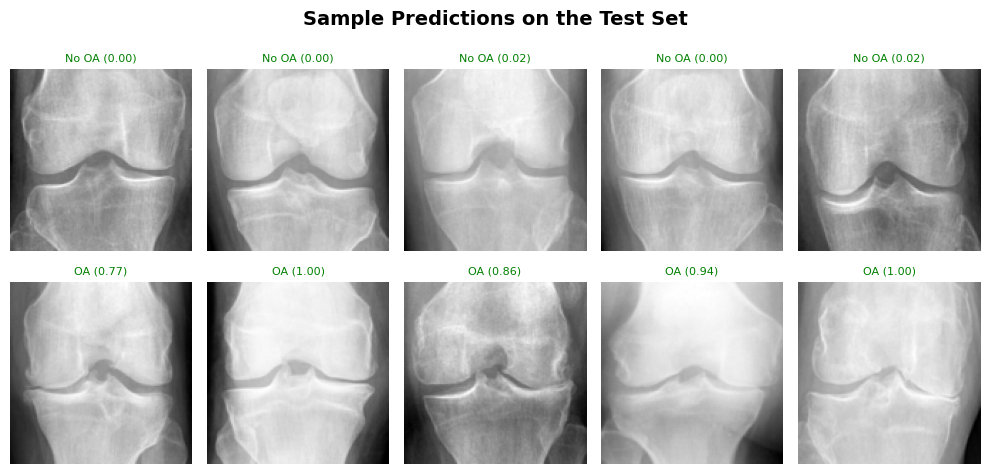

In [23]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
fig.suptitle("Sample Predictions on the Test Set", fontsize=14, fontweight="bold")
class_names = ["No OA", "OA"]

for row, label in enumerate([0, 1]):
    indices = np.where(y_test.ravel() == label)[0]
    indices = indices[indices < len(X_test_no_normalized)]
    samples = np.random.choice(indices, size=5, replace=False)
    for col, idx in enumerate(samples):
        pred = y_pred_prob[idx, 0]
        pred_label = int(pred > 0.5)
        correct = pred_label == int(label)
        axes[row, col].imshow(X_test_no_normalized[idx].squeeze(), cmap="gray")
        axes[row, col].axis("off")
        color = "green" if correct else "red"
        axes[row, col].set_title(
            f"{class_names[pred_label]} ({pred:.2f})", fontsize=8, color=color
        )

plt.tight_layout()
plt.show()

Plot ROC-AUC curve:

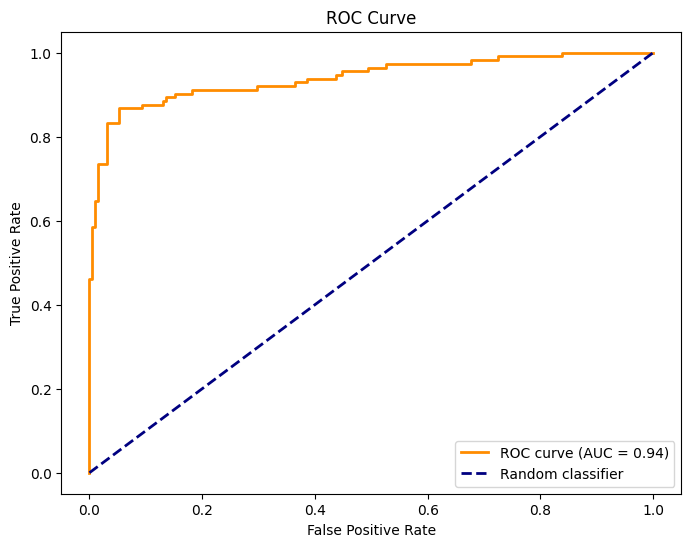

AUC Score: 0.9404


In [24]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_prob[:, 0])
roc_auc = metrics.auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

In the context of knee OA, false negatives are not catastrophic because patients will likely experience pain and return for a follow-up check, meaning the disease is unlikely to go undetected entirely. False positives however can have a more direct negative impact, potentially leading to unnecessary surgery and lifestyle changes. Despite false positives being more costly, ensuring the model catches most actual OA cases remains the primary clinical goal. Therefore we aimed for a TPR of around 90% to ensure high sensitivity, while keeping the FPR as low as possible within that constraint, and chose the optimal threshold accordingly.

In [25]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_prob[:, 0])

target_tpr = 0.90
valid = np.where(tpr >= target_tpr)[0]

best_idx = valid[np.argmin(fpr[valid])]
best_threshold = thresholds[best_idx]

print(f"Threshold:   {best_threshold:.4f}")
print(f"TPR/Recall:  {tpr[best_idx]:.4f}")
print(f"FPR:         {fpr[best_idx]:.4f}")
print(f"Specificity: {1 - fpr[best_idx]:.4f}")

Threshold:   0.0773
TPR/Recall:  0.9027
FPR:         0.1510
Specificity: 0.8490


Check if the threshold actually makes sense by plotting the distribution of classifications and the chosen threshold.

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step


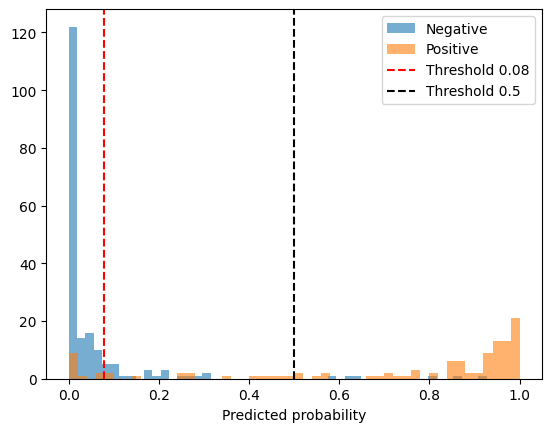

In [26]:
y_pred = model_final.predict(X_test).flatten()

# Separate predictions by true class
pos_preds = y_pred[y_test == 1]
neg_preds = y_pred[y_test == 0]

plt.hist(neg_preds, bins=50, alpha=0.6, label="Negative")
plt.hist(pos_preds, bins=50, alpha=0.6, label="Positive")
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f"Threshold {best_threshold:.2f}")
plt.axvline(x=0.5, color='black', linestyle='--', label="Threshold 0.5")
plt.xlabel("Predicted probability")
plt.legend()
plt.show()

The final confusion matrix:

Baseline model - Confusion Matrix, threshold=0.0773 TP=101 FP=29 FN=12 TN=163


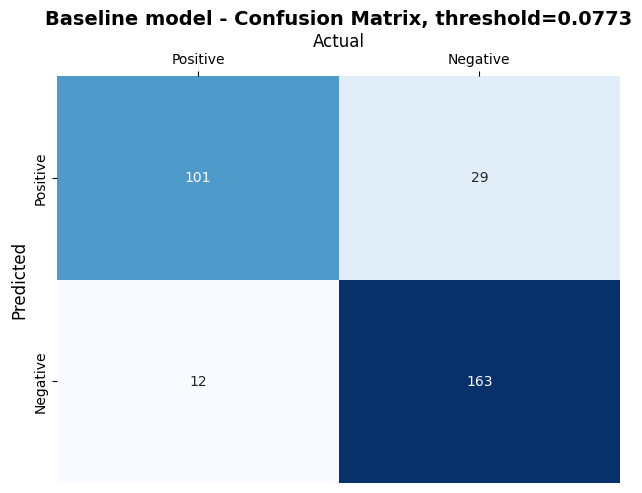

In [27]:
y_pred = (y_pred_prob > best_threshold).astype(int)
plot_confusion_matrix(y_test, y_pred, title=f"Baseline model - Confusion Matrix, threshold={best_threshold:.4f}")

The implications of these results are discussed in the final report. 